## Preamble and Datasets

<IPython.core.display.Javascript object>


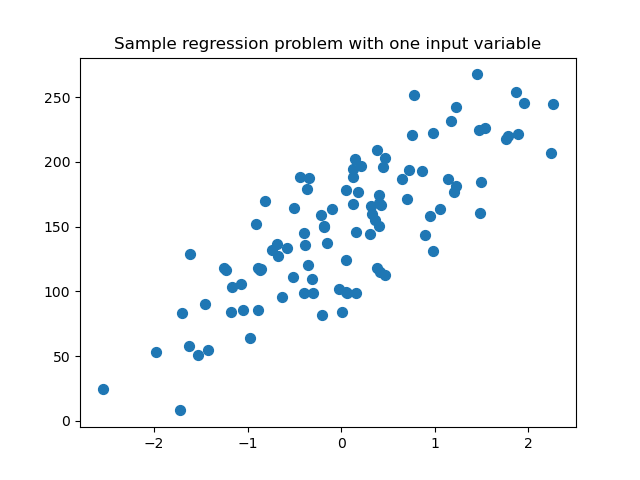

<IPython.core.display.Javascript object>


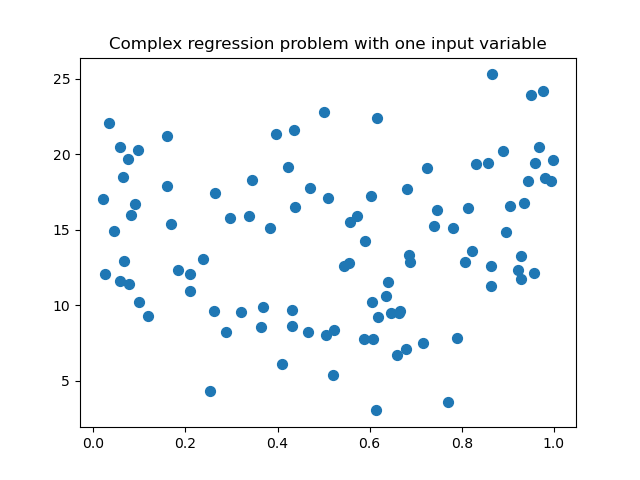

<IPython.core.display.Javascript object>


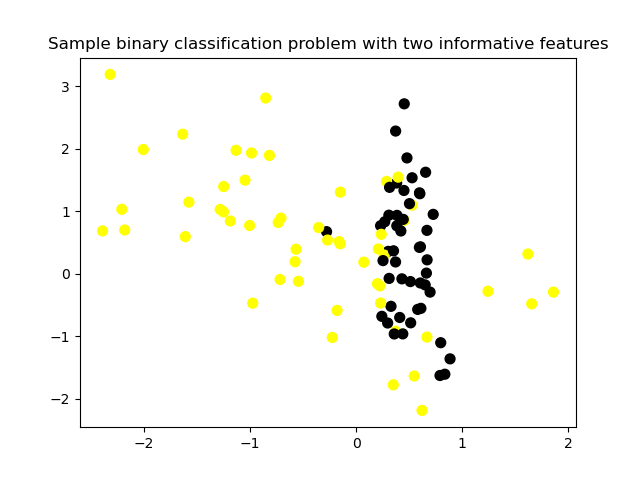

<IPython.core.display.Javascript object>


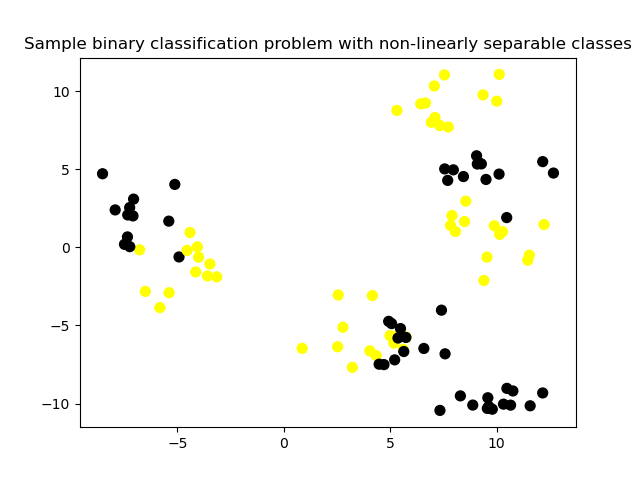

In [6]:
#Cargar librerías y datos como en modeulos previos
%matplotlib notebook
import numpy as np
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification, make_blobs
from matplotlib.colors import ListedColormap
from sklearn.datasets import load_breast_cancer
from adspy_shared_utilities8 import load_crime_dataset


cmap_bold = ListedColormap(['#FFFF00', '#00FF00', '#0000FF','#000000'])

# fruits dataset
fruits = pd.read_table('C://trabajo 2022//Python//Applied Machine Learning in Python//fruit_data_with_colors.txt')

feature_names_fruits = ['height', 'width', 'mass', 'color_score']
X_fruits = fruits[feature_names_fruits]
y_fruits = fruits['fruit_label']
target_names_fruits = ['apple', 'mandarin', 'orange', 'lemon']

X_fruits_2d = fruits[['height', 'width']]
y_fruits_2d = fruits['fruit_label']

# synthetic dataset for simple regression
from sklearn.datasets import make_regression
plt.figure()
plt.title('Sample regression problem with one input variable')
X_R1, y_R1 = make_regression(n_samples = 100, n_features=1,
                            n_informative=1, bias = 150.0,
                            noise = 30, random_state=0)
plt.scatter(X_R1, y_R1, marker= 'o', s=50)
plt.show()

# synthetic dataset for more complex regression
from sklearn.datasets import make_friedman1
plt.figure()
plt.title('Complex regression problem with one input variable')
X_F1, y_F1 = make_friedman1(n_samples = 100, n_features = 7,
                           random_state=0)

plt.scatter(X_F1[:, 2], y_F1, marker= 'o', s=50)
plt.show()

# synthetic dataset for classification (binary)
plt.figure()
plt.title('Sample binary classification problem with two informative features')
X_C2, y_C2 = make_classification(n_samples = 100, n_features=2,
                                n_redundant=0, n_informative=2,
                                n_clusters_per_class=1, flip_y = 0.1,
                                class_sep = 0.5, random_state=0)
plt.scatter(X_C2[:, 0], X_C2[:, 1], marker= 'o',
           c=y_C2, s=50, cmap=cmap_bold)
plt.show()

# more difficult synthetic dataset for classification (binary)
# with classes that are not linearly separable
X_D2, y_D2 = make_blobs(n_samples = 100, n_features = 2,
                       centers = 8, cluster_std = 1.3,
                       random_state = 4)
y_D2 = y_D2 % 2
plt.figure()
plt.title('Sample binary classification problem with non-linearly separable classes')
plt.scatter(X_D2[:,0], X_D2[:,1], c=y_D2,
           marker= 'o', s=50, cmap=cmap_bold)
plt.show()

# Breast cancer dataset for classification
cancer = load_breast_cancer()
(X_cancer, y_cancer) = load_breast_cancer(return_X_y = True)

# Communities and Crime dataset
(X_crime, y_crime) = load_crime_dataset()

## Neural networks

#### Activation functions

<IPython.core.display.Javascript object>


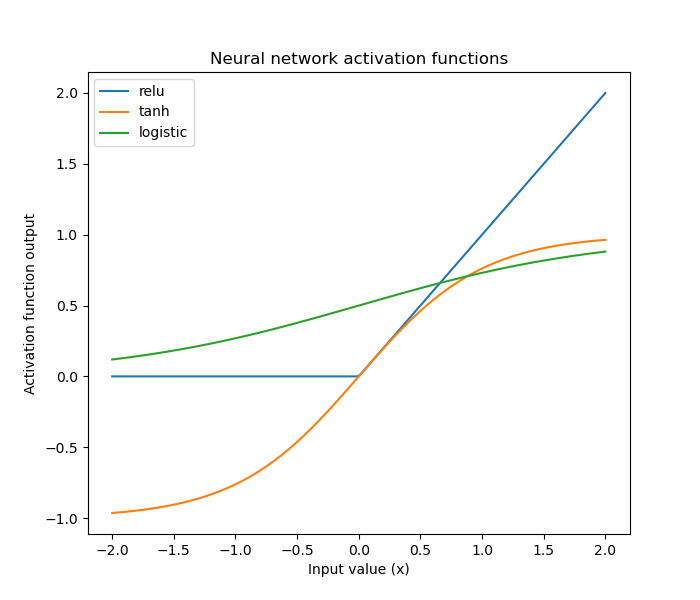

In [7]:
%matplotlib notebook
import numpy as np
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt

#Gráfica de cada función de activación
#Rango de valores desde -2 a 2
xrange = np.linspace(-2, 2, 200)

plt.figure(figsize=(7,6))
#RELU es una función que brinca así que aquí al tomar el máximo entre el rango 
#y cero, se obtiene 0 para los números entre -2 hasta el 0 y x para x en el rango mayor a  0 hasta 2
plt.plot(xrange, np.maximum(xrange, 0), label = 'relu')
#Tangente hiperbólica
plt.plot(xrange, np.tanh(xrange), label = 'tanh')
#Función logística
plt.plot(xrange, 1 / (1 + np.exp(-xrange)), label = 'logistic')
plt.legend()
plt.title('Neural network activation functions')
plt.xlabel('Input value (x)')
plt.ylabel('Activation function output')

plt.show()

### Neural networks: Classification

#### Synthetic dataset 1: single hidden layer

<IPython.core.display.Javascript object>


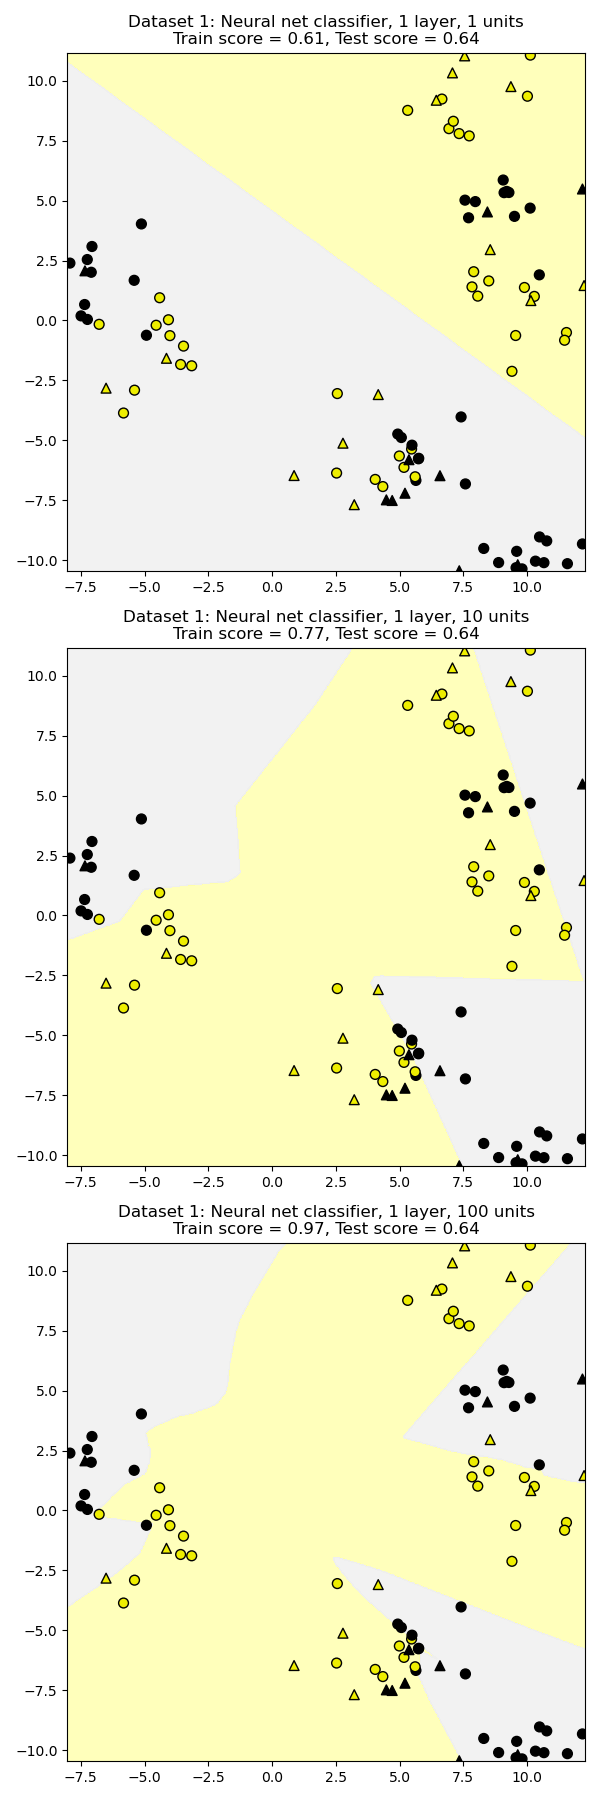

In [9]:
#Multilayer Perceptron (librería MLP) para perceptrón multicapa
from sklearn.neural_network import MLPClassifier
from adspy_shared_utilities8 import plot_class_regions_for_classifier_subplot

#usamos los datos que tienen output binario y dos inputs cuantitativos
#Obtener muestra de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_D2, y_D2, random_state=0)
#Figura
fig, subaxes = plt.subplots(3, 1, figsize=(6,18))
#Creamos un diccionario entre los números 1, 10 y 100 que es el número de nodos ocultos
#en la única capa que se usa en el perceptron y los subejes
for units, axis in zip([1, 10, 100], subaxes):
    #Tamaño de las capas ocultas según los valores 1, 10 y 100. Ajuste sobre la muestra de entrenamiento,
    #la función de activación por default es la RELU. Funciona oprimizando una función de pérdida logarítmica, la cual
    #queremos minimizar (para minimizar la pérdida),'lbfgs' is an optimizer in the family of quasi-Newton methods, también 
    #está la opción de stochastic gradinet descent, gradient descent indica que se minimiza usando el gradiente en el que
    #disminuye la pérdida, que es gamma*gradiente de la función de pérdida con respecto a los pesos, donde gamma
    #indica la rapidez con la que se desciende (learning rate). En stochastic gradinet descent no se utilizan todos los datos 
    #en el cáluclo del gradiente sino solo muestras (batches). Solver por default es adam que funciona mejor para datos grandes,
    #en cambio lbfgs para datos chicos
    # Por default learning rate es constante  y de 0.01.
    #El máximo de iteraciones es max_iter, el cual por default es de
    #200, con este default dice que no converge y por eso lo aumenté.
    #random state tiene que ver con los valores inciales que se usan para los pesos
    #Si no se especifica nada, se usaría una sola capa oculta con 100 nodos.
    #La función de activación en la capa de salida (output) es especificada por el comando de manera automatizada,
    #siendo logistic cuando el output es binario o softmax cuando hay varias categorías en el output.
    #De igual forma, la función de pérdida que se optimiza por default es log-loss (cross entropy)
    #OJO: En la lectura se usa función de activación entre el input y las capas ocultas y entre estas, pero no para
    #la última capa y el output, que no coincide con lo del libro de Hastie. Quizás Python funciona así, y entonces una sola
    #capa oculta con un solo nodo corresponde a la regresión logística, lo cual no es cierto con la especificación de Hastie
    nnclf = MLPClassifier(hidden_layer_sizes = [units], solver='lbfgs', max_iter=500,
                         random_state = 0).fit(X_train, y_train)
    
    title = 'Dataset 1: Neural net classifier, 1 layer, {} units'.format(units)
    #Gráfica para representar en las distintas subgráficas asociadas a distinto tamaño de las capas ocultas
    #las regiones que corresponden a cada grupo (son dos), representando con círculos los valores en la muestra de
    #entrenamiento y triángulos en la de prueba
    plot_class_regions_for_classifier_subplot(nnclf, X_train, y_train,
                                             X_test, y_test, title, axis)
    plt.tight_layout()

#### Synthetic dataset 1: two hidden layers

<IPython.core.display.Javascript object>


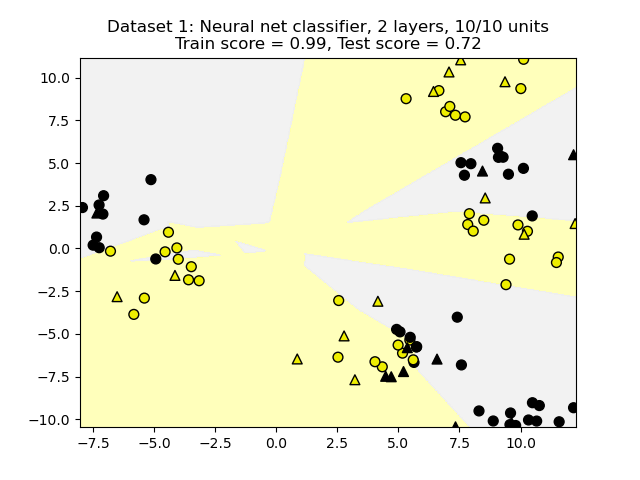

In [10]:
from adspy_shared_utilities8 import plot_class_regions_for_classifier
#Nuevamente usaos los mismos datos y dividimos en muestra de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_D2, y_D2, random_state=0)
#Incluímos dos capas ocultas, hidden_layer_sizes = [10, 10], de tamaño 10 cada una
nnclf = MLPClassifier(hidden_layer_sizes = [10, 10], solver='lbfgs',max_iter=500,
                     random_state = 0).fit(X_train, y_train)
#regiones generadas con este campio en el número de capas ocultas
plot_class_regions_for_classifier(nnclf, X_train, y_train, X_test, y_test,
                                 'Dataset 1: Neural net classifier, 2 layers, 10/10 units')

#### Regularization parameter: alpha

<IPython.core.display.Javascript object>


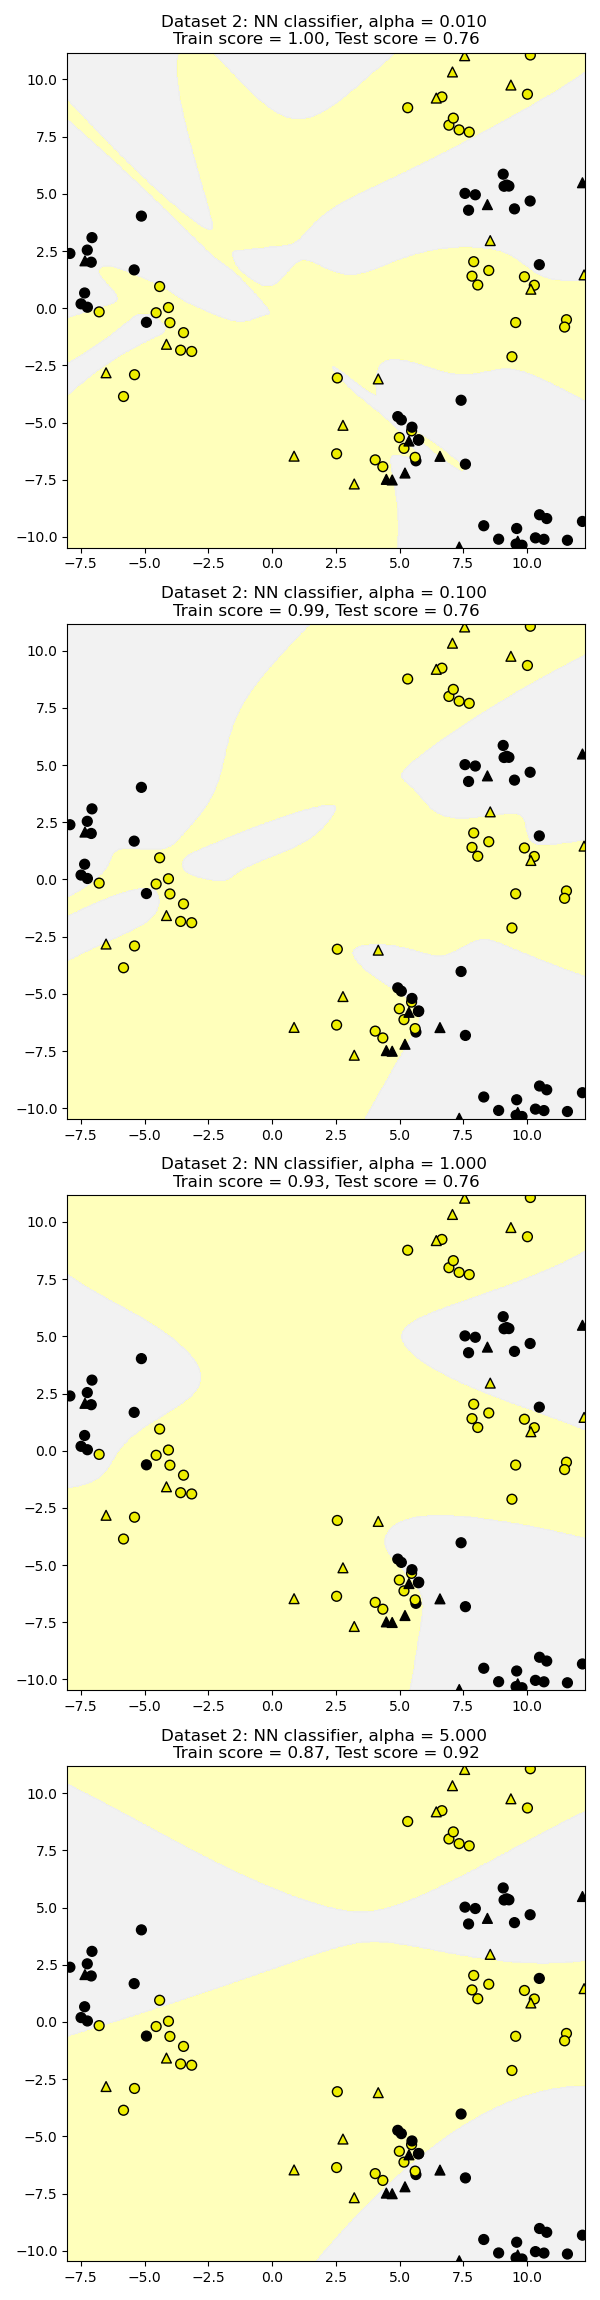

C:\Users\Usuario\anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:549: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
C:\Users\Usuario\anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:549: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


In [15]:
X_train, X_test, y_train, y_test = train_test_split(X_D2, y_D2, random_state=0)

fig, subaxes = plt.subplots(4, 1, figsize=(6, 23))
# alpha es L2 penalty (regularization term) parameter, o sea un parámetro de regularización sobre los pesos, similar al de
#regresiones lasso y ridge. alpha aka penalty term, that combats overfitting by constraining the size of the weights. 
#Increasing alpha may fix high variance (a sign of overfitting) by encouraging smaller weights, resulting in
#a decision boundary plot that appears with lesser curvatures. 

#Vemos que a mayor alpha se suavizan las regiones por lo cual hay menos sobreajuste,
#peor ajuste en el conjunto de entrenamiento, pero mejor en el de prueba. Esto es aumenta el sesgo, pero
#disminuye la varianza

#Se hace una liga entre los distintos niveles de alpha y varios subejes de subgráficas
for this_alpha, axis in zip([0.01, 0.1, 1.0, 5.0], subaxes):
    #La función de activación ahora es tangente hiperbólica, la alpha se varía y hay dos capas
    #ocultas con 100 nodos cada una
    nnclf = MLPClassifier(solver='lbfgs', activation = 'tanh', max_iter=4000,
                         alpha = this_alpha,
                         hidden_layer_sizes = [100, 100],
                         random_state = 0).fit(X_train, y_train)
    
    title = 'Dataset 2: NN classifier, alpha = {:.3f} '.format(this_alpha)
    #Gráfica de las regiones para separar los grupos con los elementos del conjunto de entrenamiento (círculos)
    #y prueba (triángulos)
    plot_class_regions_for_classifier_subplot(nnclf, X_train, y_train,
                                             X_test, y_test, title, axis)
    plt.tight_layout()    

#### The effect of different choices of activation function

<IPython.core.display.Javascript object>


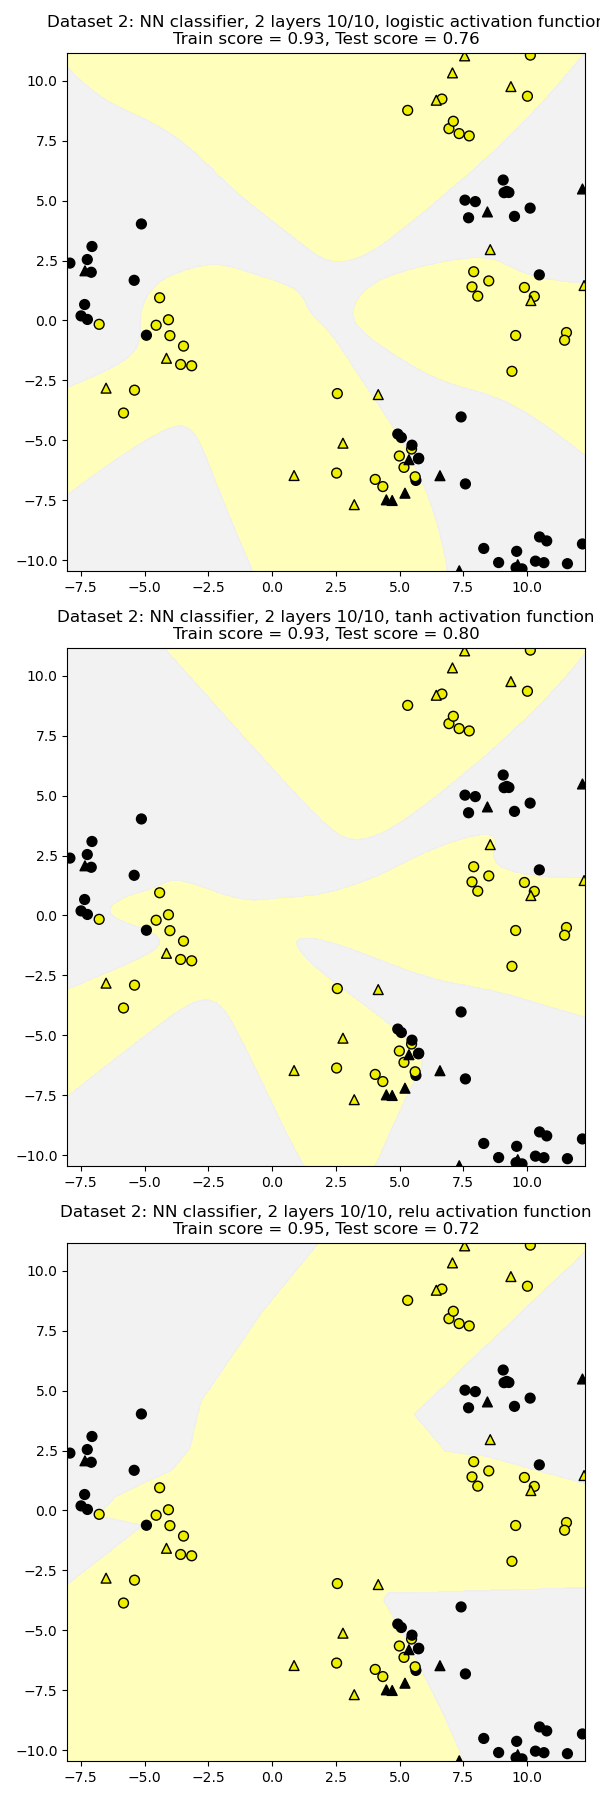

C:\Users\Usuario\anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:549: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
C:\Users\Usuario\anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:549: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
C:\Users\Usuario\anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:549: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. 

In [16]:
#Mismos datos divididos en muestra de entrenamiento y rueba
X_train, X_test, y_train, y_test = train_test_split(X_D2, y_D2, random_state=0)

fig, subaxes = plt.subplots(3, 1, figsize=(6,18))
#Hacemos un diccionario uniendo la función de activación (tres opciones) y subejes de subgráficas
for this_activation, axis in zip(['logistic', 'tanh', 'relu'], subaxes):
    #Usamos un alpha de 0.1, la función de activación va variando, y hay dos capas ocultas con 10 nodos cada una
    nnclf = MLPClassifier(solver='lbfgs', activation = this_activation,
                         alpha = 0.1, hidden_layer_sizes = [10, 10], max_iter=500,
                         random_state = 0).fit(X_train, y_train)
    
    title = 'Dataset 2: NN classifier, 2 layers 10/10, {} \
activation function'.format(this_activation)
    #Nuevamente las regiones como en previas gráficas
    plot_class_regions_for_classifier_subplot(nnclf, X_train, y_train,
                                             X_test, y_test, title, axis)
    plt.tight_layout()

### Neural networks: Regression

<IPython.core.display.Javascript object>


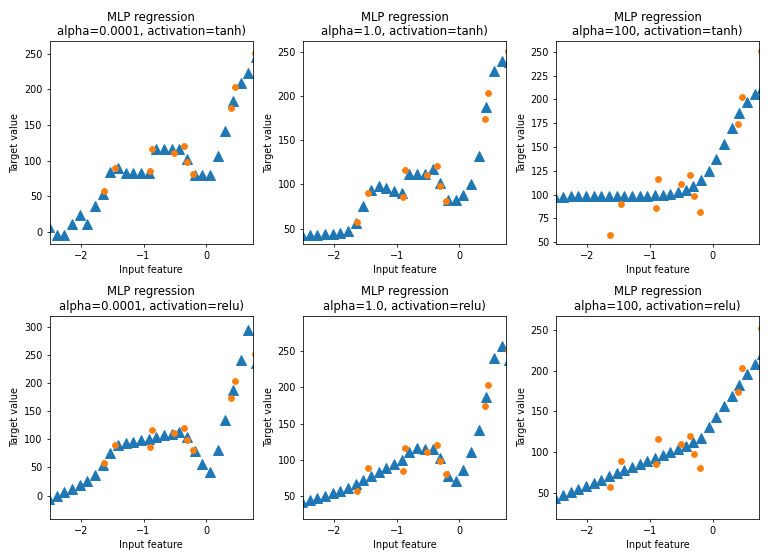

C:\Users\Usuario\anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:549: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
C:\Users\Usuario\anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:549: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


In [23]:
#Caso en que la respuesta es cuantitativa, trabajamos sobre los datos con un solo input y un output (cuantitativo)

#Por default en MLPregressor se considera que la función de pérdida es el ECM y la función de activavión
#al output es la identidad
from sklearn.neural_network import MLPRegressor

fig, subaxes = plt.subplots(2, 3, figsize=(11,8), dpi=70)
#Predicciones sobre una rango de -3 a 3 dividido en 50 
X_predict_input = np.linspace(-3, 3, 50).reshape(-1,1)
#División en muestra de prueba y entrenamiento
X_train, X_test, y_train, y_test = train_test_split(X_R1[0::5], y_R1[0::5], random_state = 0)
#Dividimos por función de activación (tanh y RELU) para obtener distintas subgráficas
for thisaxisrow, thisactivation in zip(subaxes, ['tanh', 'relu']):
    #Vamos a variar también el valor de la penalización
    for thisalpha, thisaxis in zip([0.0001, 1.0, 100], thisaxisrow):
        #Ajuste de modelo con dos capas ocultas con 100 nodos cada una
        mlpreg = MLPRegressor(hidden_layer_sizes = [100,100], max_iter=2000,
                             activation = thisactivation,
                             alpha = thisalpha,
                             solver = 'lbfgs').fit(X_train, y_train)
        #Predicción sobre el modelo ajustado usando las nuevas xs que se dieron antes al principio
        y_predict_output = mlpreg.predict(X_predict_input)
        thisaxis.set_xlim([-2.5, 0.75]) #En el eje X la gráfica solo muestra desde -2.5 hasta 0.75 (abarcaba desde -3 a 3)
        thisaxis.plot(X_predict_input, y_predict_output, #Gráfica de dispersión del input contra output
                      #predichos como triángulos
                     '^', markersize = 10)
        thisaxis.plot(X_train, y_train, 'o') #Gráfica del input contra el output en el conjunto de entrenamiento como círculos 
        thisaxis.set_xlabel('Input feature')
        thisaxis.set_ylabel('Target value')
        thisaxis.set_title('MLP regression\nalpha={}, activation={})'
                          .format(thisalpha, thisactivation))
        plt.tight_layout()

In [19]:
X_predict_input = np.linspace(-3, 3, 50).reshape(-1,1)
X_predict_input

array([[-3.        ],
       [-2.87755102],
       [-2.75510204],
       [-2.63265306],
       [-2.51020408],
       [-2.3877551 ],
       [-2.26530612],
       [-2.14285714],
       [-2.02040816],
       [-1.89795918],
       [-1.7755102 ],
       [-1.65306122],
       [-1.53061224],
       [-1.40816327],
       [-1.28571429],
       [-1.16326531],
       [-1.04081633],
       [-0.91836735],
       [-0.79591837],
       [-0.67346939],
       [-0.55102041],
       [-0.42857143],
       [-0.30612245],
       [-0.18367347],
       [-0.06122449],
       [ 0.06122449],
       [ 0.18367347],
       [ 0.30612245],
       [ 0.42857143],
       [ 0.55102041],
       [ 0.67346939],
       [ 0.79591837],
       [ 0.91836735],
       [ 1.04081633],
       [ 1.16326531],
       [ 1.28571429],
       [ 1.40816327],
       [ 1.53061224],
       [ 1.65306122],
       [ 1.7755102 ],
       [ 1.89795918],
       [ 2.02040816],
       [ 2.14285714],
       [ 2.26530612],
       [ 2.3877551 ],
       [ 2

#### Application to real-world dataset for classification

In [24]:
#Ajuste en datos de cáncer
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import MinMaxScaler

#La forma de escalar es entre 0 y 1 de acuerdo al mínimo y máximo
scaler = MinMaxScaler()
#División en muestra de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_cancer, y_cancer, random_state = 0)
#rescalamos los inputs de muestra y entrenamiento
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
#Ajuste con dos capas oculatas de tamaño 100 y parámetro de regularización de 5 
clf = MLPClassifier(hidden_layer_sizes = [100, 100], alpha = 5.0,
                   random_state = 0, solver='lbfgs').fit(X_train_scaled, y_train)
#Clasificación correcta en cada muestra
print('Breast cancer dataset')
print('Accuracy of NN classifier on training set: {:.2f}'
     .format(clf.score(X_train_scaled, y_train)))
print('Accuracy of NN classifier on test set: {:.2f}'
     .format(clf.score(X_test_scaled, y_test)))

Breast cancer dataset
Accuracy of NN classifier on training set: 0.98
Accuracy of NN classifier on test set: 0.97
